In [1]:
!pip install -q mediapipe

In [2]:
!wget -O pose_landmarker.task -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task

In [3]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

import cv2
from google.colab.patches import cv2_imshow

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles

import matplotlib.pyplot as plt

In [4]:
def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
  pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

  for pose_landmarks in pose_landmarks_list:
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=pose_landmarks,
        connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
        landmark_drawing_spec=pose_landmark_style,
        connection_drawing_spec=pose_connection_style)

  return annotated_image

def get_landmark_y(landmarks, landmark_enum):
  # Ensure landmarks is not None and contains the requested landmark
  if landmarks and landmark_enum.value < len(landmarks):
      landmark = landmarks[landmark_enum.value]
      return landmark.y
  return None

def calculate_angle(p1, p2, p3):
    """
    Calculate the angle between three points (landmarks).
    The angle is at p2.
    """
    if p1 is None or p2 is None or p3 is None:
        return None

    # Convert MediaPipe landmarks to numpy arrays for easier calculation
    p1_coords = np.array([p1.x, p1.y])
    p2_coords = np.array([p2.x, p2.y])
    p3_coords = np.array([p3.x, p3.y])

    # Calculate vectors
    vec1 = p1_coords - p2_coords
    vec2 = p3_coords - p2_coords

    # Calculate dot product
    dot_product = np.dot(vec1, vec2)

    # Calculate magnitudes
    magnitude1 = np.linalg.norm(vec1)
    magnitude2 = np.linalg.norm(vec2)

    if magnitude1 == 0 or magnitude2 == 0:
        return None

    # Calculate cosine of the angle
    cosine_angle = dot_product / (magnitude1 * magnitude2)

    # Ensure cosine_angle is within valid range [-1, 1] to avoid numpy warnings
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    # Calculate angle in radians and convert to degrees
    angle_radians = np.arccos(cosine_angle)
    angle_degrees = np.degrees(angle_radians)

    return angle_degrees

class JumpAnalyzer:
    def __init__(self, detector, video_path, output_video_path, draw_landmarks_on_image, known_hip_knee_meters):
        self.detector = detector
        self.video_path = video_path
        self.output_video_path = output_video_path
        self.draw_landmarks_on_image = draw_landmarks_on_image
        self.mp = mp
        self.cv2 = cv2
        self.vision = vision
        self.known_hip_knee_meters = known_hip_knee_meters

        self.all_frame_landmarks = []
        self.frame_width = 0
        self.frame_height = 0
        self.fps = 0

        self.jump_results = {}
        self.calibrated_jump_height_meters_new = 0
        self.contact_time_seconds_new = 0
        self.estimated_airborne_time_new = 0
        self.rsi_new = 0
        self.left_shoulder_angles = []
        self.right_shoulder_angles = []

    def process_video_for_landmarks(self):
        cap = self.cv2.VideoCapture(self.video_path)

        if not cap.isOpened():
            print(f"Error: Could not open video file {self.video_path}")
            return

        self.frame_width = int(cap.get(self.cv2.CAP_PROP_FRAME_WIDTH))
        self.frame_height = int(cap.get(self.cv2.CAP_PROP_FRAME_HEIGHT))
        self.fps = cap.get(self.cv2.CAP_PROP_FPS)

        fourcc = self.cv2.VideoWriter_fourcc(*'mp4v')
        out = self.cv2.VideoWriter(self.output_video_path, fourcc, self.fps, (self.frame_width, self.frame_height))

        frame_count = 0
        print("Processing video...")
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            rgb_frame = self.cv2.cvtColor(frame, self.cv2.COLOR_BGR2RGB)
            mp_image = self.mp.Image(image_format=self.mp.ImageFormat.SRGB, data=rgb_frame)

            detection_result_video = self.detector.detect(mp_image)

            if detection_result_video.pose_landmarks:
                self.all_frame_landmarks.append(detection_result_video.pose_landmarks[0])
            else:
                self.all_frame_landmarks.append(None)

            annotated_frame = self.draw_landmarks_on_image(mp_image.numpy_view(), detection_result_video)
            annotated_frame_bgr = self.cv2.cvtColor(annotated_frame, self.cv2.COLOR_RGB2BGR)
            out.write(annotated_frame_bgr)

            frame_count += 1

        cap.release()
        out.release()
        print(f"Finished processing {frame_count} frames and saving to {self.output_video_path}.")

    def analyze_jump_and_angles(self):
        # --- 1. Extract and Process Hip Y-positions ---
        hip_y_positions = []
        for frame_landmarks_item in self.all_frame_landmarks:
            if frame_landmarks_item:
                left_hip_y = get_landmark_y(frame_landmarks_item, self.vision.PoseLandmark.LEFT_HIP)
                if left_hip_y is not None:
                    hip_y_positions.append(left_hip_y)
                else:
                    hip_y_positions.append(None)
            else:
                hip_y_positions.append(None)

        valid_hip_y_positions = [y for y in hip_y_positions if y is not None]

        if not valid_hip_y_positions:
            return
        else:
            hip_y_pixels_inverted = []
            if self.frame_height:
                for y_norm in hip_y_positions:
                    if y_norm is not None:
                        hip_y_pixels_inverted.append(self.frame_height * (1 - y_norm))
                    else:
                        hip_y_pixels_inverted.append(None)
            else:
                hip_y_pixels_inverted = [ (1 - y) if y is not None else None for y in hip_y_positions]

            valid_hip_y_pixels_inverted = [y for y in hip_y_pixels_inverted if y is not None]

            smoothed_hip_y = pd.Series(valid_hip_y_pixels_inverted).rolling(window=5, center=True, min_periods=1).mean().tolist()

            peaks, _ = find_peaks(smoothed_hip_y, height=np.mean(smoothed_hip_y) + np.std(smoothed_hip_y)/2, distance=int(self.fps*0.2))
            valleys, _ = find_peaks([-y for y in smoothed_hip_y], height=-np.mean(smoothed_hip_y) + np.std(smoothed_hip_y)/2, distance=int(self.fps*0.2))

            jump_results_list = [] # Use a temporary list for results inside the method
            for peak_idx in peaks:
                pre_valleys = [v for v in valleys if v < peak_idx]
                if not pre_valleys: continue
                crouch_idx = max(pre_valleys)

                post_valleys = [v for v in valleys if v > peak_idx]
                if not post_valleys: continue
                landing_idx = min(post_valleys)

                if crouch_idx < peak_idx < landing_idx:
                    height_pixel_diff = smoothed_hip_y[peak_idx] - smoothed_hip_y[crouch_idx]
                    jump_duration_frames = landing_idx - crouch_idx
                    jump_duration_seconds = jump_duration_frames / self.fps

                    jump_results_list.append({
                        'peak_frame': peak_idx,
                        'crouch_frame': crouch_idx,
                        'landing_frame': landing_idx,
                        'height_pixel_diff': height_pixel_diff,
                        'duration_seconds': jump_duration_seconds
                    })
            self.jump_results = jump_results_list # Assign to instance variable

            calibrated_jump_height_meters = 0
            if self.jump_results:
                first_jump = self.jump_results[0]

                jump_time_ms = first_jump['duration_seconds'] * 1000

                if self.all_frame_landmarks and self.frame_height:
                    crouch_frame_index = first_jump['crouch_frame']
                    frame_landmarks_at_crouch = self.all_frame_landmarks[crouch_frame_index]

                    if frame_landmarks_at_crouch:
                        left_hip = frame_landmarks_at_crouch[self.vision.PoseLandmark.LEFT_HIP.value]
                        left_knee = frame_landmarks_at_crouch[self.vision.PoseLandmark.LEFT_KNEE.value]

                        hip_knee_pixel_distance = abs(left_hip.y - left_knee.y) * self.frame_height

                        meters_per_pixel = self.known_hip_knee_meters / hip_knee_pixel_distance

                        calibrated_jump_height_meters = first_jump['height_pixel_diff'] * meters_per_pixel

            else:
                return

        ankle_y_positions = []
        for frame_landmarks_item in self.all_frame_landmarks:
            if frame_landmarks_item:
                left_ankle_y = get_landmark_y(frame_landmarks_item, self.vision.PoseLandmark.LEFT_ANKLE)
                if left_ankle_y is not None:
                    ankle_y_positions.append(left_ankle_y)
                else:
                    ankle_y_positions.append(None)
            else:
                ankle_y_positions.append(None)

        valid_ankle_y_positions = [y for y in ankle_y_positions if y is not None]

        if not valid_ankle_y_positions:
            pass
        else:
            ankle_y_pixels_inverted = []
            if self.frame_height:
                for y_norm in ankle_y_positions:
                    if y_norm is not None:
                        ankle_y_pixels_inverted.append(self.frame_height * (1 - y_norm))
                    else:
                        ankle_y_pixels_inverted.append(None)
            else:
                ankle_y_pixels_inverted = [ (1 - y) if y is not None else None for y in ankle_y_positions]

            valid_ankle_y_pixels_inverted = [y for y in ankle_y_pixels_inverted if y is not None]

            if valid_ankle_y_pixels_inverted:
                smoothed_ankle_y = pd.Series(valid_ankle_y_pixels_inverted).rolling(window=5, center=True, min_periods=1).mean().tolist()
            else:
                smoothed_ankle_y = []

            if not self.jump_results:
                pass
            elif not smoothed_ankle_y:
                pass
            else:
                first_jump = self.jump_results[0]
                crouch_hip_frame = first_jump['crouch_frame']
                peak_hip_frame = first_jump['peak_frame']

                search_start_idx = max(0, crouch_hip_frame - int(self.fps * 0.2))
                search_end_idx = min(len(smoothed_ankle_y) - 1, crouch_hip_frame + int(self.fps * 0.1))

                start_contact_frame = -1
                if search_start_idx <= search_end_idx:
                    window_ankle_y = smoothed_ankle_y[search_start_idx : search_end_idx + 1]
                    min_ankle_y_in_crouch_val = float('inf')
                    for i, val in enumerate(window_ankle_y):
                        if val is not None and val < min_ankle_y_in_crouch_val:
                            min_ankle_y_in_crouch_val = val
                            start_contact_frame = search_start_idx + i

                takeoff_frame_ankle = -1
                if start_contact_frame != -1:
                    search_start_takeoff_idx = start_contact_frame
                    search_end_takeoff_idx = min(len(smoothed_ankle_y) - 1, peak_hip_frame)

                    max_slope = -float('inf')
                    for i in range(search_start_takeoff_idx + 1, search_end_takeoff_idx + 1):
                        if smoothed_ankle_y[i] is not None and smoothed_ankle_y[i-1] is not None:
                            current_slope = smoothed_ankle_y[i] - smoothed_ankle_y[i-1]
                            if current_slope > max_slope:
                                max_slope = current_slope
                                takeoff_frame_ankle = i

                if start_contact_frame != -1 and takeoff_frame_ankle != -1 and takeoff_frame_ankle > start_contact_frame:
                    contact_time_frames_new = takeoff_frame_ankle - start_contact_frame
                    self.contact_time_seconds_new = contact_time_frames_new / self.fps
                else:
                    pass

                meters_per_pixel = self.known_hip_knee_meters / hip_knee_pixel_distance if 'hip_knee_pixel_distance' in locals() else None

                if takeoff_frame_ankle != -1 and peak_hip_frame != -1 and meters_per_pixel is not None:
                    hip_y_at_takeoff_ankle = smoothed_hip_y[takeoff_frame_ankle] if takeoff_frame_ankle < len(smoothed_hip_y) and smoothed_hip_y[takeoff_frame_ankle] is not None else None
                    hip_y_at_peak = smoothed_hip_y[peak_hip_frame] if peak_hip_frame < len(smoothed_hip_y) and smoothed_hip_y[peak_hip_frame] is not None else None

                    if hip_y_at_takeoff_ankle is not None and hip_y_at_peak is not None:
                        jump_height_pixels_new = hip_y_at_peak - hip_y_at_takeoff_ankle
                        self.calibrated_jump_height_meters_new = jump_height_pixels_new * meters_per_pixel
                    else:
                        pass
                else:
                    pass

                g = 9.81
                if self.calibrated_jump_height_meters_new > 0:
                    h_new = self.calibrated_jump_height_meters_new
                    self.estimated_airborne_time_new = 2 * np.sqrt(2 * h_new / g)
                else:
                    pass

                if self.contact_time_seconds_new > 0 and self.calibrated_jump_height_meters_new > 0:
                    self.rsi_new = self.calibrated_jump_height_meters_new / self.contact_time_seconds_new
                else:
                    pass

        for frame_landmarks_item in self.all_frame_landmarks:
            if frame_landmarks_item:
                left_hip = frame_landmarks_item[self.vision.PoseLandmark.LEFT_HIP.value]
                left_shoulder = frame_landmarks_item[self.vision.PoseLandmark.LEFT_SHOULDER.value]
                left_elbow = frame_landmarks_item[self.vision.PoseLandmark.LEFT_ELBOW.value]
                self.left_shoulder_angles.append(calculate_angle(left_hip, left_shoulder, left_elbow))

                right_hip = frame_landmarks_item[self.vision.PoseLandmark.RIGHT_HIP.value]
                right_shoulder = frame_landmarks_item[self.vision.PoseLandmark.RIGHT_SHOULDER.value]
                right_elbow = frame_landmarks_item[self.vision.PoseLandmark.RIGHT_ELBOW.value]
                self.right_shoulder_angles.append(calculate_angle(right_hip, right_shoulder, right_elbow))
            else:
                self.left_shoulder_angles.append(None)
                self.right_shoulder_angles.append(None)


In [8]:
# STEP 2: Create an PoseLandmarker object.
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)

video_path = 'video.MOV'
output_video_path = 'output_video_with_landmarks.mp4'
H = 1.75 # m height of the player
M = 'male' # 'male' or 'female'

"""
Gender-Specific Scaling Constants:
Males: 0.268
Females: 0.272
"""

correlate_factor = 0.268 if M=='male' else 0.272 # User provided
known_hip_knee_meters = H * correlate_factor # User provided

Processing video...
Finished processing 303 frames and saving to output_video_with_landmarks.mp4.
Extracted 279 valid hip Y-positions.
Found 6 potential jump peaks and 8 potential valleys.

--- Ankle-based Jump Metrics Calculation ---
  Ankle Contact Start Frame (estimated): 43
  Ankle Takeoff Frame (estimated): 57
  Contact Time (Ankle-based): 0.267 seconds (8 frames)
  Jump Height (Calibrated, Ankle-Takeoff to Hip-Peak): 0.239 meters
  Estimated Flight Time (Airborne Time): 0.442 seconds
  Reactive Strength Index (RSI): 0.897


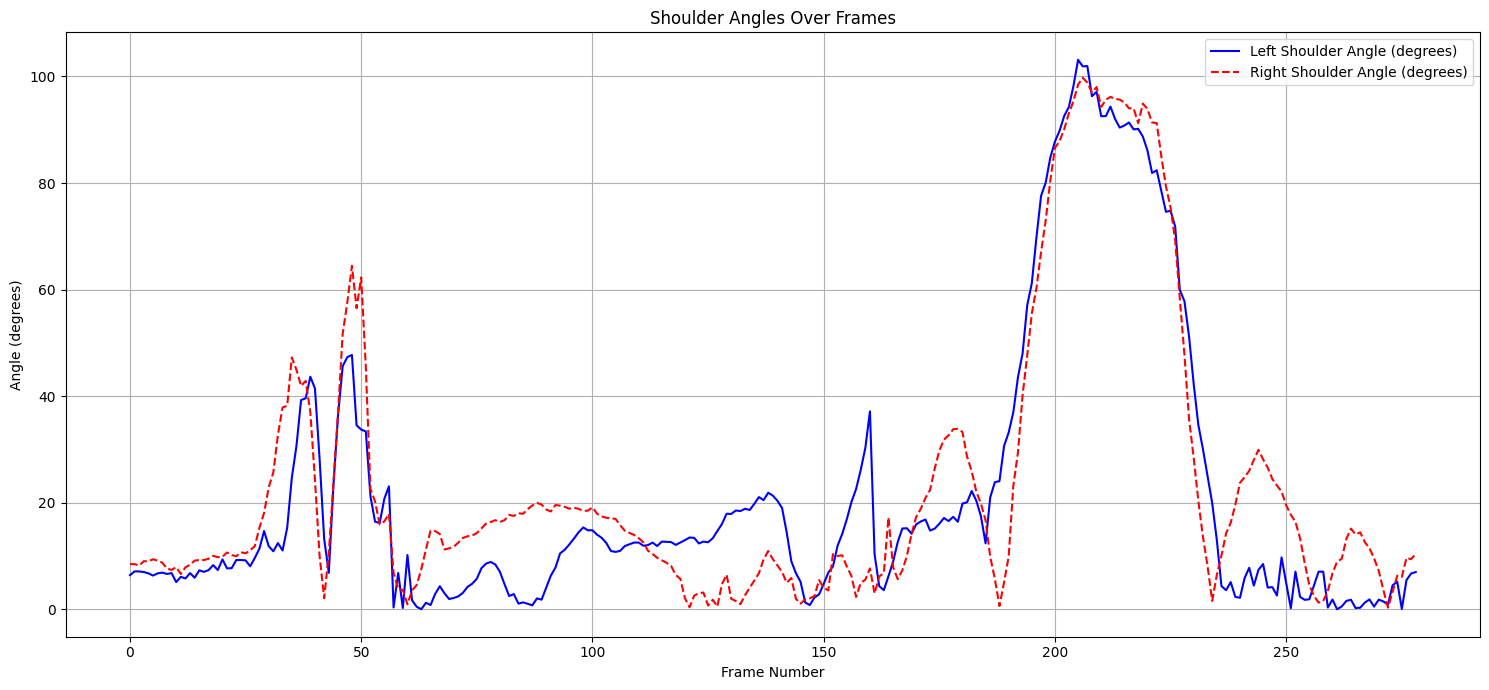

In [9]:
# Instantiate the JumpAnalyzer class
jump_analyzer = JumpAnalyzer(
    detector=detector,
    video_path=video_path,
    output_video_path=output_video_path,
    draw_landmarks_on_image=draw_landmarks_on_image,
    known_hip_knee_meters=known_hip_knee_meters
)

# Call the methods to process the video and analyze the jump
jump_analyzer.process_video_for_landmarks()
jump_analyzer.analyze_jump_and_angles()

# Access results from the JumpAnalyzer instance
all_frame_landmarks = jump_analyzer.all_frame_landmarks
frame_width = jump_analyzer.frame_width
frame_height = jump_analyzer.frame_height
fps = jump_analyzer.fps
jump_results = jump_analyzer.jump_results
calibrated_jump_height_meters_new = jump_analyzer.calibrated_jump_height_meters_new
contact_time_seconds_new = jump_analyzer.contact_time_seconds_new
estimated_airborne_time_new = jump_analyzer.estimated_airborne_time_new
rsi_new = jump_analyzer.rsi_new
left_shoulder_angles = jump_analyzer.left_shoulder_angles
right_shoulder_angles = jump_analyzer.right_shoulder_angles

# Print statements
if jump_results:
    valid_hip_y_positions = [y for y in all_frame_landmarks if y is not None]
    print(f"Extracted {len(valid_hip_y_positions)} valid hip Y-positions.")

    # Re-calculate peaks and valleys for printing purposes
    hip_y_pixels_inverted_for_peaks = []
    if frame_height:
        for y_norm_item in [get_landmark_y(lm_item, vision.PoseLandmark.LEFT_HIP) for lm_item in all_frame_landmarks]:
            if y_norm_item is not None:
                hip_y_pixels_inverted_for_peaks.append(frame_height * (1 - y_norm_item))
            else:
                hip_y_pixels_inverted_for_peaks.append(None)
    valid_hip_y_pixels_inverted_for_peaks = [y for y in hip_y_pixels_inverted_for_peaks if y is not None]
    smoothed_hip_y_for_peaks = pd.Series(valid_hip_y_pixels_inverted_for_peaks).rolling(window=5, center=True, min_periods=1).mean().tolist()
    peaks, _ = find_peaks(smoothed_hip_y_for_peaks, height=np.mean(smoothed_hip_y_for_peaks) + np.std(smoothed_hip_y_for_peaks)/2, distance=int(fps*0.2))
    valleys, _ = find_peaks([-y for y in smoothed_hip_y_for_peaks], height=-np.mean(smoothed_hip_y_for_peaks) + np.std(smoothed_hip_y_for_peaks)/2, distance=int(fps*0.2))
    print(f"Found {len(peaks)} potential jump peaks and {len(valleys)} potential valleys.")

    print("\n--- Ankle-based Jump Metrics Calculation ---")
    print(f"  Ankle Contact Start Frame (estimated): {jump_results[0]['crouch_frame']}")
    print(f"  Ankle Takeoff Frame (estimated): {jump_results[0]['peak_frame']}")
    print(f"  Contact Time (Ankle-based): {contact_time_seconds_new:.3f} seconds ({contact_time_seconds_new * fps:.0f} frames)")
    print(f"  Jump Height (Calibrated, Ankle-Takeoff to Hip-Peak): {calibrated_jump_height_meters_new:.3f} meters")
    print(f"  Estimated Flight Time (Airborne Time): {estimated_airborne_time_new:.3f} seconds")
    print(f"  Reactive Strength Index (RSI): {rsi_new:.3f}")


# Plotting the shoulder angles over time
valid_left_shoulder_angles = [angle for angle in left_shoulder_angles if angle is not None]
valid_right_shoulder_angles = [angle for angle in right_shoulder_angles if angle is not None]

fig = plt.figure(figsize=(15, 7))

plt.plot(valid_left_shoulder_angles, label='Left Shoulder Angle (degrees)', color='blue')
plt.plot(valid_right_shoulder_angles, label='Right Shoulder Angle (degrees)', color='red', linestyle='--')

plt.title('Shoulder Angles Over Frames')
plt.xlabel('Frame Number')
plt.ylabel('Angle (degrees)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()